In [20]:
import pandas as pd
import numpy as np
import pyodbc

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier

In [21]:
conn = pyodbc.connect(
    "Driver={SQL Server};"
    "Server=localhost;"
    "Database=ChurnDB;"
    "Trusted_Connection=yes;"
)


query = """
SELECT *
FROM Customers
"""


df = pd.read_sql(
    query,
    conn
)


df.head()

C:\Users\KIMO STORE\AppData\Local\Temp\ipykernel_11856\3241925746.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,70.70,151.65,Yes


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      7032 non-null   object 
 1   gender          7032 non-null   object 
 2   SeniorCitizen   7032 non-null   int64  
 3   Partner         7032 non-null   object 
 4   Dependents      7032 non-null   object 
 5   tenure          7032 non-null   int64  
 6   PhoneService    7032 non-null   object 
 7   MonthlyCharges  7032 non-null   float64
 8   TotalCharges    7032 non-null   float64
 9   Churn           7032 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 549.5+ KB


In [23]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], 
    errors='coerce'
)

df.dropna(inplace=True)

In [24]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = encoder.fit_transform(df[col])

In [25]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
predictions = model.predict(X_test)

In [29]:
print(
accuracy_score(y_test, predictions)
)

print(
classification_report(y_test, predictions)
)

0.7725657427149965
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1033
           1       0.61      0.41      0.49       374

    accuracy                           0.77      1407
   macro avg       0.71      0.66      0.67      1407
weighted avg       0.76      0.77      0.76      1407



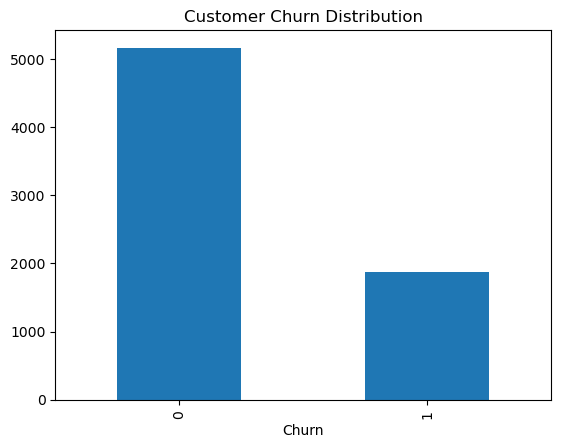

In [30]:
df['Churn'].value_counts().plot(kind='bar')

plt.title("Customer Churn Distribution")

plt.show()

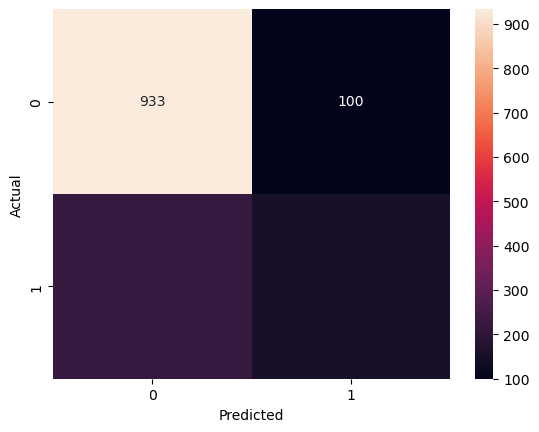

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
import pyodbc

print("installed")

installed
